Trying to understand the ITA values of the Monk scale...

In [1]:
import colour
from colour.models import (
    RGB_COLOURSPACE_sRGB,
)

from shapelysmooth import chaikin_smooth
import alphashape
import numpy as np
from PIL import Image

from pathlib import Path
import matplotlib.pyplot as plt

from paiskintonetools import setup_matplotlib  # type: ignore

setup_matplotlib(200)

In [2]:
lab_data = np.load("../Analysis/intermediate data/lab.npz")

In [3]:
srgb = np.array([lab_data["sR"], lab_data["sG"], lab_data["sB"]]).T

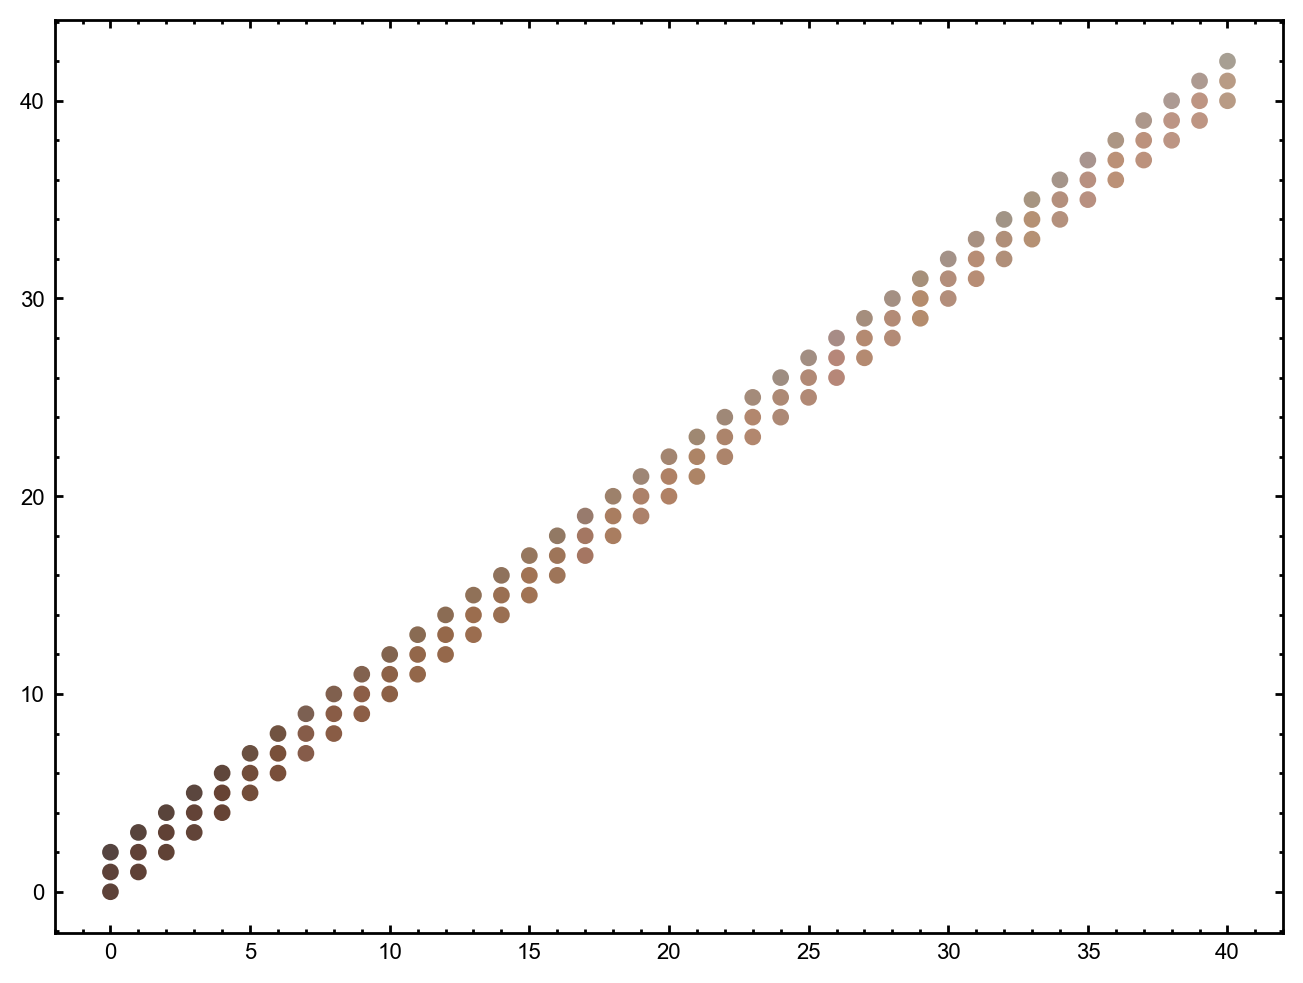

In [4]:
lab = np.array([lab_data["L"], lab_data["a"], lab_data["b"]]).T
order = np.argsort(lab[:, 0])
srgb_estimate = colour.XYZ_to_sRGB(
    colour.Lab_to_XYZ(
        lab, colour.CCS_ILLUMINANTS["CIE 1964 10 Degree Standard Observer"]["D75"]
    ),
)

to_good_rgb = (
    np.linalg.pinv(
        srgb_estimate
        # np.concatenate([srgb_estimate, np.ones((srgb_estimate.shape[0], 1))], axis=1)
    )
    @ srgb
).T

plt.scatter(
    np.arange(lab.shape[0]),
    np.arange(lab.shape[0]),
    c=(to_good_rgb @ srgb_estimate.T).T[order],
)

plt.scatter(
    np.arange(lab.shape[0]),
    np.arange(lab.shape[0]) + 1,
    c=srgb[order],
)

plt.scatter(
    np.arange(lab.shape[0]),
    np.arange(lab.shape[0]) + 2,
    c=srgb_estimate[order],
)

(30.0, 110.0)

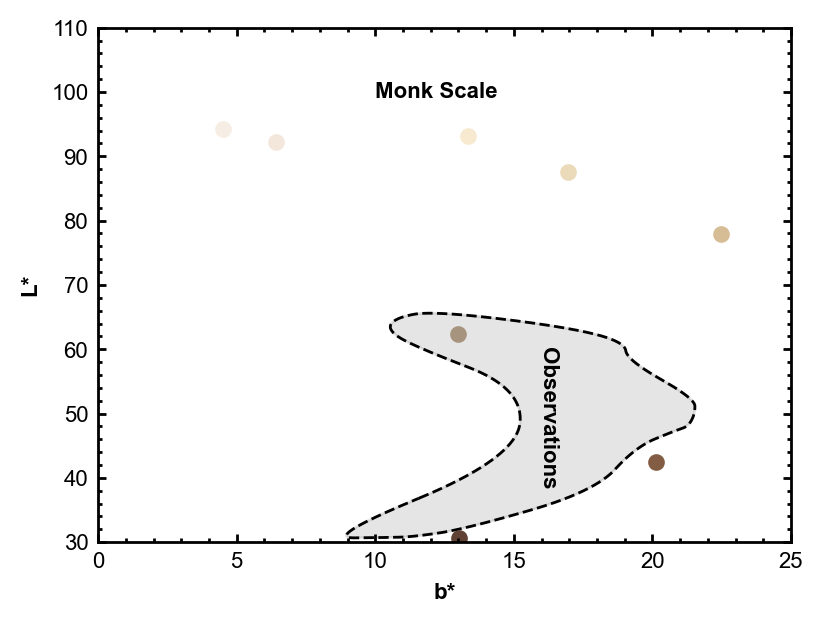

In [5]:
fig = plt.figure(figsize=(4, 3))
for file in Path("MST Swatches").glob("*.png"):
    im1 = Image.open(file)
    rgb = (np.array(im1))[:, :, :3].mean(axis=(0, 1)) / 255
    xyz = colour.sRGB_to_XYZ(rgb)
    lab = colour.XYZ_to_Lab(xyz, colour.CCS_ILLUMINANTS["cie_10_1964"]["D65"])
    plt.scatter([lab[2]], [lab[0]], color=rgb)
    xyz = colour.RGB_to_XYZ(rgb, RGB_COLOURSPACE_sRGB)
    lab = colour.XYZ_to_Lab(
        xyz,
    )
    # plt.scatter([lab[2]], [lab[0]], color=rgb, marker="x")

points = np.array([lab_data["b"], lab_data["L"]]).T
shape = chaikin_smooth(
    alphashape.alphashape(points, 0.1),  #  type:ignore
    iters=10,
)
x, y = shape.exterior.xy  #  type:ignore
plt.plot(x, y, c="k", linestyle="--", zorder=-100)
plt.fill(x, y, c="k", alpha=0.1, zorder=-100)
xc, yc = shape.centroid.xy  #  type:ignore
plt.text(
    xc[0],
    yc[0],
    "Observations",
    rotation=270,
    ha="left",
    va="center",
    fontweight="bold",
)

plt.text(
    10,
    100,
    "Monk Scale",
    ha="left",
    va="center",
    fontweight="bold",
)

plt.xlabel("b*")
plt.ylabel("L*")
plt.xlim([0, 25])
plt.ylim([30, 110])

In [6]:
lab_data["a"]

array([  6.008     ,   6.482     ,   8.254     ,   5.026     ,
         3.94      ,   6.49      ,   6.832     ,  11.086     ,
         7.312     ,   6.91      ,   8.898     ,   3.33333333,
         8.426     ,   5.938     ,   6.2       ,   7.502     ,
         7.592     ,   8.15      ,  10.128     ,   4.614     ,
         9.272     ,   6.142     ,   6.646     ,   9.254     ,
         9.33      ,   5.52      ,  10.858     ,   6.993     ,
         9.772     ,   9.466     ,   1.46333333,   6.06333333,
         9.35333333,  10.05333333,   5.18      ,   6.90333333,
         9.84      ,   7.96      ,   7.862     ,  10.944     ,  10.308     ])

In [7]:
ls = np.arange(30, 120, 0.1)
b = np.arange(0, 26, 0.1)

L, B = np.meshgrid(ls, b)
a = 7 * np.ones_like(B)

lab = np.array([L, a, B]).T

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.110921238504..1.45929984976].


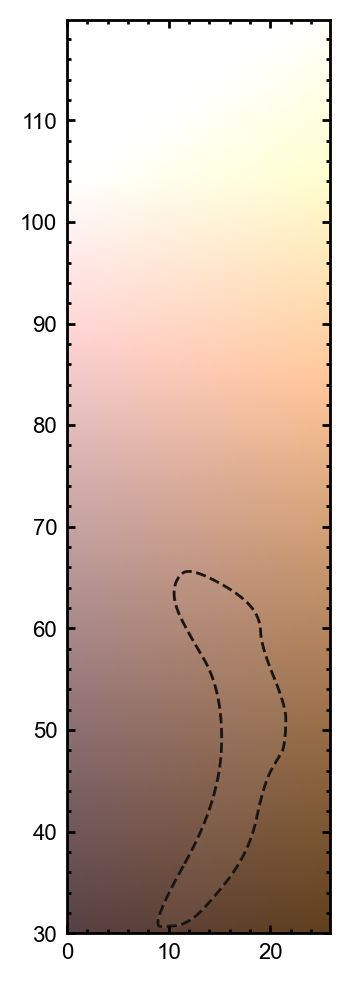

In [ ]:
plt.imshow(
    (
        to_good_rgb
        @ colour.XYZ_to_sRGB(
            colour.Lab_to_XYZ(
                lab,
                colour.CCS_ILLUMINANTS["CIE 1964 10 Degree Standard Observer"]["D75"],
            ),
        ).T.reshape((3, -1))
    )
    .reshape((3, lab.shape[1], lab.shape[0]))
    .T,
    origin="lower",
    extent=(np.min(b), np.max(b), np.min(ls), np.max(ls)),  # type:ignore
)
plt.plot(x, y, c="k", linestyle="--", zorder=100)
plt.fill(x, y, c=srgb[order[-1]], alpha=0.1, zorder=100)

In [9]:
colour.XYZ_to_sRGB(
    colour.Lab_to_XYZ(
        lab,
        colour.CCS_ILLUMINANTS["CIE 1964 10 Degree Standard Observer"]["D75"],
    ),
).T.shape

(3, 260, 900)

In [10]:
np.max(lab_data["L"])

65.973333333333329